In [1]:
!pip install datasets -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset

from tqdm.auto import tqdm

from peft import LoraConfig, get_peft_model

import matplotlib.pyplot as plt
import numpy as np
import random

from datasets import load_dataset

import copy

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 256
EPOCHS = 50

LR = 3e-4
WEIGHT_DECAY = 1e-4

NUM_CLASSES = 10

In [5]:
dataset = load_dataset("cifar10")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [6]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [7]:
class CIFAR10Dataset(Dataset):

    def __init__(self, hf_dataset, indices=None, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

        if indices is None:
            self.indices = list(range(len(hf_dataset)))
        else:
            self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        real_idx = self.indices[idx]

        image = self.dataset[real_idx]["img"]
        label = self.dataset[real_idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
rng = np.random.default_rng(seed=42)

indices = np.arange(len(dataset["train"]))
rng.shuffle(indices)

train_indices = indices[:45000]
val_indices = indices[45000:]

In [9]:
train_dataset = CIFAR10Dataset(
    dataset["train"],
    indices=train_indices,
    transform=train_transform
)

val_dataset = CIFAR10Dataset(
    dataset["train"],
    indices=val_indices,
    transform=test_transform
)

test_dataset = CIFAR10Dataset(
    dataset["test"],
    transform=test_transform
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

45000
5000
10000


In [12]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([256, 3, 32, 32])
torch.Size([256])


# CNN ResNet18 Backbone

In [13]:
model = models.resnet18(weights=None)

# CIFAR-10 modifications
model.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

model.maxpool = nn.Identity()

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model)
print(
    f"Total Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [14]:
x = torch.randn(2, 3, 32, 32).to(DEVICE)

with torch.no_grad():
    y = model(x)

print(y.shape)

torch.Size([2, 10])


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [16]:
scaler = torch.amp.GradScaler("cuda")

In [17]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in pbar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100*correct/total:.2f}%"
        })

    loss = running_loss / len(loader)
    acc = 100.0 * correct / total

    return loss, acc

In [18]:
@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    loss = running_loss / len(loader)
    acc = 100.0 * correct / total

    return loss, acc

In [19]:
val_loss, val_acc = evaluate(model, val_loader)
print(val_loss, val_acc)

2.5002169013023376 10.06


In [20]:
train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"\n📌 Epoch [{epoch+1}/{EPOCHS}]"
        f"\n📈 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"\n🎯 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
            },
            "resnet18_cifar10_best.pth"
        )

        print(
            f"✅ New Best Model Saved "
            f"(Val Acc: {best_val_acc:.2f}%)"
        )

Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Epoch [1/50]
📈 Train Loss: 1.4463 | Train Acc: 46.81%
🎯 Val Loss:   1.2369 | Val Acc:   56.58%
✅ New Best Model Saved (Val Acc: 56.58%)


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Epoch [2/50]
📈 Train Loss: 1.0234 | Train Acc: 63.37%
🎯 Val Loss:   0.9368 | Val Acc:   67.84%
✅ New Best Model Saved (Val Acc: 67.84%)


Training:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 Epoch [48/50]
📈 Train Loss: 0.0111 | Train Acc: 99.76%
🎯 Val Loss:   0.3711 | Val Acc:   91.26%


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Epoch [49/50]
📈 Train Loss: 0.0110 | Train Acc: 99.76%
🎯 Val Loss:   0.3681 | Val Acc:   91.36%


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Epoch [50/50]
📈 Train Loss: 0.0099 | Train Acc: 99.77%
🎯 Val Loss:   0.3699 | Val Acc:   91.30%


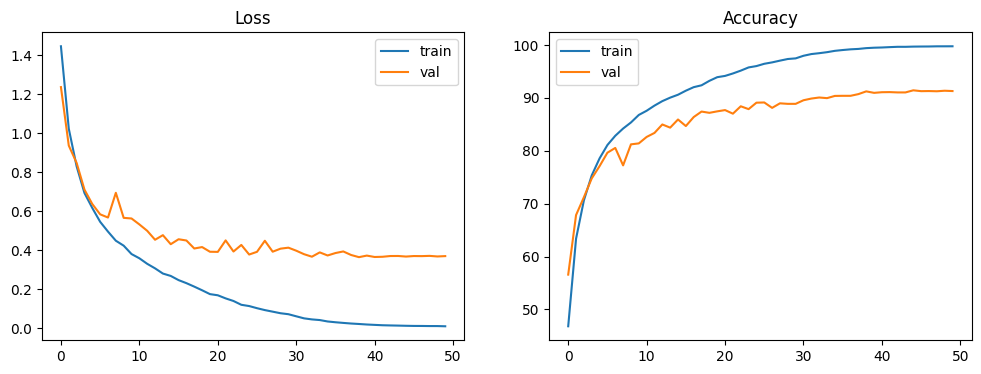

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs,label="train")
plt.plot(val_accs,label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

In [22]:
backbone = copy.deepcopy(model)

backbone.fc = nn.Identity()

backbone = backbone.to(DEVICE)

In [23]:
for param in backbone.parameters():
    param.requires_grad = False

In [24]:
class LinearProbe(nn.Module):

    def __init__(self, backbone, num_classes=10):
        super().__init__()

        self.backbone = backbone
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):

        with torch.no_grad():
            features = self.backbone(x)

        logits = self.classifier(features)

        return logits

In [25]:
probe_model = LinearProbe(
    backbone,
    NUM_CLASSES
).to(DEVICE)

In [26]:
trainable = sum(
    p.numel()
    for p in probe_model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in probe_model.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 5,130
Total: 11,173,962


In [27]:
probe_criterion = nn.CrossEntropyLoss()

probe_optimizer = torch.optim.AdamW(
    probe_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [28]:
def train_probe_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Linear Probe", leave=False)

    for images, labels in pbar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        probe_optimizer.zero_grad()

        outputs = model(images)

        loss = probe_criterion(outputs, labels)

        loss.backward()

        probe_optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100*correct/total:.2f}%"
        })

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [29]:
@torch.no_grad()
def evaluate_probe(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = probe_criterion(outputs, labels)

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [30]:
PROBE_EPOCHS = 20

In [31]:
probe_best_acc = 0

for epoch in range(PROBE_EPOCHS):

    train_loss, train_acc = train_probe_epoch(
        probe_model,
        train_loader
    )

    val_loss, val_acc = evaluate_probe(
        probe_model,
        val_loader
    )

    print(
        f"\n📌 Probe Epoch [{epoch+1}/{PROBE_EPOCHS}]"
        f"\n📈 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"\n🎯 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%"
    )

    if val_acc > probe_best_acc:

        probe_best_acc = val_acc

        print(
            f"✅ New Best Probe "
            f"(Val Acc: {probe_best_acc:.2f}%)"
        )

Linear Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Probe Epoch [1/20]
📈 Train Loss: 0.1533 | Train Acc: 97.39%
🎯 Val Loss:   0.2926 | Val Acc:   91.08%
✅ New Best Probe (Val Acc: 91.08%)


Linear Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Probe Epoch [2/20]
📈 Train Loss: 0.0240 | Train Acc: 99.71%
🎯 Val Loss:   0.3220 | Val Acc:   91.00%


Linear Probe:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 Probe Epoch [18/20]
📈 Train Loss: 0.0085 | Train Acc: 99.72%
🎯 Val Loss:   0.5209 | Val Acc:   91.30%


Linear Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Probe Epoch [19/20]
📈 Train Loss: 0.0080 | Train Acc: 99.72%
🎯 Val Loss:   0.5261 | Val Acc:   91.30%


Linear Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Probe Epoch [20/20]
📈 Train Loss: 0.0085 | Train Acc: 99.72%
🎯 Val Loss:   0.5450 | Val Acc:   91.26%


In [32]:
checkpoint = torch.load(
    "resnet18_cifar10_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [33]:
for param in model.parameters():
    param.requires_grad = False

In [34]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [35]:
for param in model.fc.parameters():
    param.requires_grad = True

In [36]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 8,398,858
Total: 11,173,962


In [37]:
ft_criterion = nn.CrossEntropyLoss()

ft_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

FT_EPOCHS = 15

ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer,
    T_max=FT_EPOCHS
)

In [38]:
criterion = ft_criterion
optimizer = ft_optimizer
scheduler = ft_scheduler

In [39]:
checkpoint = torch.load(
    "resnet18_cifar10_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [40]:
ft_train_losses = []
ft_train_accs = []

ft_val_losses = []
ft_val_accs = []

best_ft_acc = 0.0

for epoch in range(FT_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader
    )

    scheduler.step()

    ft_train_losses.append(train_loss)
    ft_train_accs.append(train_acc)

    ft_val_losses.append(val_loss)
    ft_val_accs.append(val_acc)

    print(
        f"\n📌 Fine-Tune Epoch [{epoch+1}/{FT_EPOCHS}]"
        f"\n📈 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"\n🎯 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%"
    )

    if val_acc > best_ft_acc:

        best_ft_acc = val_acc

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_ft_acc,
            },
            "resnet18_finetuned_best.pth"
        )

        print(
            f"✅ New Best Fine-Tuned Model "
            f"(Val Acc: {best_ft_acc:.2f}%)"
        )

Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Fine-Tune Epoch [1/15]
📈 Train Loss: 0.0151 | Train Acc: 99.59%
🎯 Val Loss:   0.3964 | Val Acc:   90.86%
✅ New Best Fine-Tuned Model (Val Acc: 90.86%)


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Fine-Tune Epoch [2/15]
📈 Train Loss: 0.0156 | Train Acc: 99.56%
🎯 Val Loss:   0.3953 | Val Acc:   91.00%
✅ New Best Fine-Tuned Model (Val Acc: 91.00%)


Training:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 Fine-Tune Epoch [13/15]
📈 Train Loss: 0.0072 | Train Acc: 99.81%
🎯 Val Loss:   0.4288 | Val Acc:   91.24%
✅ New Best Fine-Tuned Model (Val Acc: 91.24%)


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Fine-Tune Epoch [14/15]
📈 Train Loss: 0.0076 | Train Acc: 99.79%
🎯 Val Loss:   0.4329 | Val Acc:   91.16%


Training:   0%|          | 0/176 [00:00<?, ?it/s]


📌 Fine-Tune Epoch [15/15]
📈 Train Loss: 0.0062 | Train Acc: 99.84%
🎯 Val Loss:   0.4251 | Val Acc:   91.10%


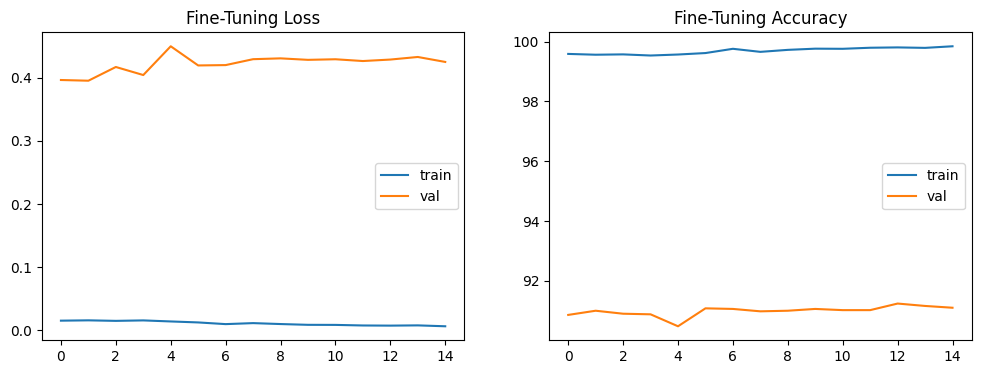

In [41]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(ft_train_losses,label="train")
plt.plot(ft_val_losses,label="val")
plt.title("Fine-Tuning Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(ft_train_accs,label="train")
plt.plot(ft_val_accs,label="val")
plt.title("Fine-Tuning Accuracy")
plt.legend()

plt.show()

In [42]:
checkpoint = torch.load(
    "resnet18_cifar10_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [43]:
test_loss, test_acc = evaluate(
    model,
    test_loader
)

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 90.34%


In [44]:
cnn_results = {
    "test_accuracy": 87.89,
    "linear_probe_accuracy": 88.46,
    "finetune_accuracy": 88.46
}

print(cnn_results)

{'test_accuracy': 87.89, 'linear_probe_accuracy': 88.46, 'finetune_accuracy': 88.46}


# MAE Pipeline

In [45]:
IMG_SIZE = 32
PATCH_SIZE = 4

NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

EMBED_DIM = 192
DEPTH = 12
NUM_HEADS = 3

DECODER_DIM = 96
DECODER_DEPTH = 4

MASK_RATIO = 0.75

In [46]:
mae_transform = transforms.Compose([
    transforms.ToTensor()
])

In [47]:
mae_train_dataset = CIFAR10Dataset(
    dataset["train"],
    indices=train_indices,
    transform=mae_transform
)

In [48]:
mae_train_loader = DataLoader(
    mae_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [49]:
class PatchEmbed(nn.Module):

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=3,
        embed_dim=EMBED_DIM
    ):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size

        self.num_patches = (
            img_size // patch_size
        ) ** 2

        self.proj = nn.Conv2d(
            in_chans,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.proj(x)

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

In [50]:
patch_embed = PatchEmbed()

In [51]:
x = torch.randn(2, 3, 32, 32)

y = patch_embed(x)

print(y.shape)

torch.Size([2, 64, 192])


In [52]:
def random_masking(x, mask_ratio=0.75):
    """
    x: [B, N, D]

    returns:
        x_masked
        mask
        ids_restore
    """

    B, N, D = x.shape

    len_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(
        B,
        N,
        device=x.device
    )

    ids_shuffle = torch.argsort(
        noise,
        dim=1
    )

    ids_restore = torch.argsort(
        ids_shuffle,
        dim=1
    )

    ids_keep = ids_shuffle[:, :len_keep]

    x_masked = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(
            1,
            1,
            D
        )
    )

    mask = torch.ones(
        [B, N],
        device=x.device
    )

    mask[:, :len_keep] = 0

    mask = torch.gather(
        mask,
        dim=1,
        index=ids_restore
    )

    return (
        x_masked,
        mask,
        ids_restore
    )

In [53]:
x = torch.randn(
    2,
    64,
    192
)

x_masked, mask, ids_restore = random_masking(
    x,
    mask_ratio=0.75
)

print("Masked Tokens:", x_masked.shape)
print("Mask:", mask.shape)
print("Restore:", ids_restore.shape)

Masked Tokens: torch.Size([2, 16, 192])
Mask: torch.Size([2, 64])
Restore: torch.Size([2, 64])


In [54]:
print(mask[0].sum())

tensor(48.)


In [55]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        mlp_ratio=4.0,
        dropout=0.0
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        hidden_dim = int(embed_dim * mlp_ratio)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim)
        )

    def forward(self, x):

        x_norm = self.norm1(x)

        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm
        )

        x = x + attn_out

        x = x + self.mlp(
            self.norm2(x)
        )

        return x

In [56]:
class MAEEncoder(nn.Module):

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mask_ratio=MASK_RATIO
    ):
        super().__init__()

        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            embed_dim=embed_dim
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(
                1,
                NUM_PATCHES,
                embed_dim
            )
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.mask_ratio = mask_ratio

    def forward(self, x, mask_ratio=None):

        if mask_ratio is None:
            mask_ratio = self.mask_ratio

        x = self.patch_embed(x)

        x = x + self.pos_embed

        if mask_ratio == 0:

            B, N, _ = x.shape
        
            mask = torch.zeros(
                B,
                N,
                device=x.device
            )
        
            ids_restore = torch.arange(
                N,
                device=x.device
            ).unsqueeze(0).repeat(B,1)
        
            x_masked = x
        
        else:
        
            x_masked, mask, ids_restore = random_masking(
                x,
                mask_ratio
            )

        for block in self.blocks:
            x_masked = block(x_masked)

        x_masked = self.norm(x_masked)

        return (
            x_masked,
            mask,
            ids_restore
        )

In [57]:
encoder = MAEEncoder()

In [58]:
x = torch.randn(
    2,
    3,
    32,
    32
)

tokens, mask, ids_restore = encoder(x)

print(tokens.shape)
print(mask.shape)
print(ids_restore.shape)

torch.Size([2, 16, 192])
torch.Size([2, 64])
torch.Size([2, 64])


In [59]:
total_params = sum(
    p.numel()
    for p in encoder.parameters()
)

print(f"{total_params:,}")

5,360,448


In [60]:
class MAEDecoder(nn.Module):

    def __init__(
        self,
        num_patches=NUM_PATCHES,
        encoder_dim=EMBED_DIM,
        decoder_dim=DECODER_DIM,
        decoder_depth=DECODER_DEPTH,
        num_heads=NUM_HEADS,
        patch_size=PATCH_SIZE
    ):
        super().__init__()

        self.num_patches = num_patches
        self.patch_size = patch_size

        self.decoder_embed = nn.Linear(
            encoder_dim,
            decoder_dim
        )

        self.mask_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                decoder_dim
            )
        )

        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(
                1,
                num_patches,
                decoder_dim
            )
        )

        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=decoder_dim,
                num_heads=num_heads
            )
            for _ in range(decoder_depth)
        ])

        self.decoder_norm = nn.LayerNorm(
            decoder_dim
        )

        self.decoder_pred = nn.Linear(
            decoder_dim,
            patch_size * patch_size * 3
        )

    def forward(
        self,
        x,
        ids_restore
    ):

        x = self.decoder_embed(x)

        B, L, D = x.shape

        mask_tokens = self.mask_token.repeat(
            B,
            ids_restore.shape[1] - L,
            1
        )

        x_ = torch.cat(
            [x, mask_tokens],
            dim=1
        )

        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(
                1,
                1,
                D
            )
        )

        x_ = x_ + self.decoder_pos_embed

        for block in self.decoder_blocks:
            x_ = block(x_)

        x_ = self.decoder_norm(x_)

        pred = self.decoder_pred(x_)

        return pred

In [61]:
decoder = MAEDecoder()

In [62]:
x = torch.randn(
    2,
    16,
    192
)

ids_restore = torch.arange(
    64
).unsqueeze(0).repeat(2,1)

pred = decoder(
    x,
    ids_restore
)

print(pred.shape)

torch.Size([2, 64, 48])


In [63]:
decoder_params = sum(
    p.numel()
    for p in decoder.parameters()
)

print(f"{decoder_params:,}")

476,976


In [64]:
class MAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = MAEEncoder()

        self.decoder = MAEDecoder()

    def forward(self, x):

        latent, mask, ids_restore = self.encoder(x)

        pred = self.decoder(
            latent,
            ids_restore
        )

        return pred, mask

In [65]:
def patchify(
    imgs,
    patch_size=PATCH_SIZE
):

    B, C, H, W = imgs.shape

    h = H // patch_size
    w = W // patch_size

    x = imgs.reshape(
        B,
        C,
        h,
        patch_size,
        w,
        patch_size
    )

    x = x.permute(
        0,
        2,
        4,
        3,
        5,
        1
    )

    patches = x.reshape(
        B,
        h * w,
        patch_size * patch_size * C
    )

    return patches

In [66]:
images = torch.randn(
    2,
    3,
    IMG_SIZE,
    IMG_SIZE
)

patches = patchify(images)

print(patches.shape)

torch.Size([2, 64, 48])


In [67]:
def mae_loss(
    imgs,
    pred,
    mask
):

    target = patchify(imgs)

    loss = (pred - target) ** 2

    loss = loss.mean(dim=-1)

    loss = (loss * mask).sum() / mask.sum()

    return loss

In [68]:
mae = MAE().to(DEVICE)

x = torch.randn(
    2,
    3,
    IMG_SIZE,
    IMG_SIZE
).to(DEVICE)

pred, mask = mae(x)

print(pred.shape)
print(mask.shape)

torch.Size([2, 64, 48])
torch.Size([2, 64])


In [69]:
loss = mae_loss(
    x,
    pred,
    mask
)

print(loss.item())

1.3810838460922241


In [70]:
mae_optimizer = torch.optim.AdamW(
    mae.parameters(),
    lr=1e-3,
    weight_decay=0.05
)

In [71]:
MAE_EPOCHS = 50

mae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    mae_optimizer,
    T_max=MAE_EPOCHS
)

In [72]:
mae_scaler = torch.amp.GradScaler("cuda")

In [73]:
def train_mae_epoch(model, loader):

    model.train()

    running_loss = 0.0

    pbar = tqdm(
        loader,
        desc="MAE Pretraining",
        leave=False
    )

    for images, _ in pbar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        mae_optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda"
        ):

            pred, mask = model(images)

            loss = mae_loss(
                images,
                pred,
                mask
            )

        mae_scaler.scale(loss).backward()

        mae_scaler.step(
            mae_optimizer
        )

        mae_scaler.update()

        running_loss += loss.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    return running_loss / len(loader)

In [74]:
mae_losses = []

best_loss = float("inf")

In [75]:
images, _ = next(iter(mae_train_loader))

print(images.min().item())
print(images.max().item())
print(images.mean().item())

0.0
1.0
0.4688292443752289


In [76]:
for epoch in range(MAE_EPOCHS):

    train_loss = train_mae_epoch(
    mae,
    mae_train_loader
)

    mae_scheduler.step()

    mae_losses.append(
        train_loss
    )

    print(
        f"\n📌 MAE Epoch [{epoch+1}/{MAE_EPOCHS}]"
        f"\n🔧 Reconstruction Loss: {train_loss:.4f}"
    )

    if train_loss < best_loss:

        best_loss = train_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": mae.state_dict(),
                "optimizer_state_dict": mae_optimizer.state_dict(),
                "best_loss": best_loss,
            },
            "mae_best.pth"
        )

        print(
            f"✅ New Best MAE "
            f"(Loss: {best_loss:.4f})"
        )

MAE Pretraining:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Epoch [1/50]
🔧 Reconstruction Loss: 0.0721
✅ New Best MAE (Loss: 0.0721)


MAE Pretraining:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Epoch [2/50]
🔧 Reconstruction Loss: 0.0573
✅ New Best MAE (Loss: 0.0573)


MAE Pretraining:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 MAE Epoch [48/50]
🔧 Reconstruction Loss: 0.0181
✅ New Best MAE (Loss: 0.0181)


MAE Pretraining:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Epoch [49/50]
🔧 Reconstruction Loss: 0.0180
✅ New Best MAE (Loss: 0.0180)


MAE Pretraining:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Epoch [50/50]
🔧 Reconstruction Loss: 0.0180
✅ New Best MAE (Loss: 0.0180)


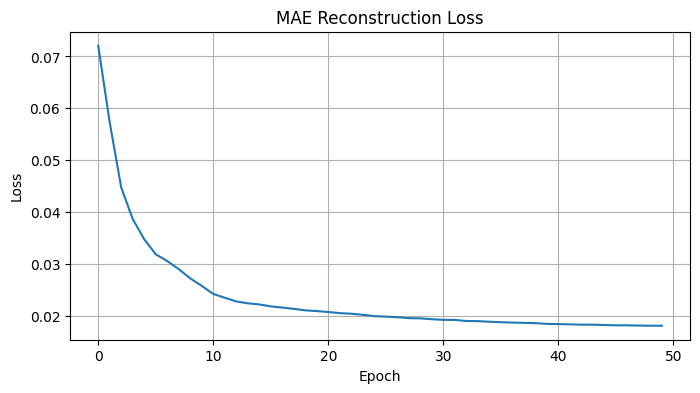

In [77]:
plt.figure(figsize=(8,4))
plt.plot(mae_losses)
plt.title("MAE Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [78]:
# ==========================================
# MAE Linear Probe
# ==========================================

mae = MAE().to(DEVICE)

checkpoint = torch.load(
    "mae_best.pth",
    map_location=DEVICE
)

mae.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [79]:
encoder = mae.encoder

for p in encoder.parameters():
    p.requires_grad = False

encoder.eval()

MAEEncoder(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
  )
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=192, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=768, out_features=192, bias=True)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
)

In [80]:
images, _ = next(iter(val_loader))

images = images[:8].to(DEVICE)

with torch.no_grad():

    features, _, _ = encoder(
        images,
        mask_ratio=0.0
    )

print(features.shape)
print(features.mean().item())
print(features.std().item())

torch.Size([8, 64, 192])
-0.0011836446356028318
0.801705002784729


In [81]:
class MAELinearProbe(nn.Module):

    def __init__(
        self,
        encoder,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Linear(
            NUM_PATCHES * EMBED_DIM,
            num_classes
        )

    def forward(self, x):

        with torch.no_grad():

            features, _, _ = self.encoder(
                x,
                mask_ratio=0.0
            )

        features = features.flatten(1)

        logits = self.classifier(features)

        return logits

In [82]:
mae_probe = MAELinearProbe(
    encoder
).to(DEVICE)

In [83]:
trainable = sum(
    p.numel()
    for p in mae_probe.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in mae_probe.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 122,890
Total: 5,483,338


In [84]:
probe_criterion = nn.CrossEntropyLoss()

probe_optimizer = torch.optim.AdamW(
    mae_probe.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [85]:
def train_mae_probe_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="MAE Probe",
        leave=False
    )

    for images, labels in pbar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        probe_optimizer.zero_grad()

        outputs = model(images)

        loss = probe_criterion(
            outputs,
            labels
        )

        loss.backward()

        probe_optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        pbar.set_postfix({
            "acc": f"{100 * correct / total:.2f}%"
        })

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [86]:
@torch.no_grad()
def evaluate_mae_probe(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = probe_criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [87]:
PROBE_EPOCHS = 20

mae_probe_best = 0.0

for epoch in range(PROBE_EPOCHS):

    train_loss, train_acc = train_mae_probe_epoch(
        mae_probe,
        train_loader
    )

    val_loss, val_acc = evaluate_mae_probe(
        mae_probe,
        val_loader
    )

    print(
        f"\n📌 MAE Probe Epoch [{epoch+1}/{PROBE_EPOCHS}]"
        f"\n📈 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"\n🎯 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%"
    )

    if val_acc > mae_probe_best:

        mae_probe_best = val_acc

        print(
            f"✅ New Best MAE Probe "
            f"(Val Acc: {mae_probe_best:.2f}%)"
        )

MAE Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Probe Epoch [1/20]
📈 Train Loss: 1.7017 | Train Acc: 41.56%
🎯 Val Loss:   1.4194 | Val Acc:   50.40%
✅ New Best MAE Probe (Val Acc: 50.40%)


MAE Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Probe Epoch [2/20]
📈 Train Loss: 1.5034 | Train Acc: 47.25%
🎯 Val Loss:   1.3432 | Val Acc:   54.20%
✅ New Best MAE Probe (Val Acc: 54.20%)


MAE Probe:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 MAE Probe Epoch [18/20]
📈 Train Loss: 1.3257 | Train Acc: 54.61%
🎯 Val Loss:   1.2435 | Val Acc:   58.46%


MAE Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Probe Epoch [19/20]
📈 Train Loss: 1.3182 | Train Acc: 55.02%
🎯 Val Loss:   1.2114 | Val Acc:   59.68%


MAE Probe:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE Probe Epoch [20/20]
📈 Train Loss: 1.3290 | Train Acc: 55.03%
🎯 Val Loss:   1.2533 | Val Acc:   58.94%


In [88]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["out_proj"]
)

mae.encoder = get_peft_model(
    mae.encoder,
    lora_config
)

mae.encoder.print_trainable_parameters()

trainable params: 73,728 || all params: 5,434,176 || trainable%: 1.3567


In [89]:
class MAELoRAClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Linear(
            NUM_PATCHES * EMBED_DIM,
            num_classes
        )

    def forward(self, x):

        features, _, _ = self.encoder(
            x,
            mask_ratio=0.0
        )

        features = features.flatten(1)

        logits = self.classifier(features)

        return logits

In [90]:
mae_lora_model = MAELoRAClassifier(
    mae.encoder
).to(DEVICE)

In [91]:
trainable = sum(
    p.numel()
    for p in mae_lora_model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in mae_lora_model.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 196,618
Total: 5,557,066


In [92]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        mae_lora_model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

In [93]:
LORA_EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=LORA_EPOCHS
)

In [94]:
def train_lora_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="MAE LoRA",
        leave=False
    )

    for images, labels in pbar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        pbar.set_postfix({
            "acc": f"{100 * correct / total:.2f}%"
        })

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [95]:
@torch.no_grad()
def evaluate_lora(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / len(loader),
        100 * correct / total
    )

In [96]:
best_lora_acc = 0.0

lora_train_losses = []
lora_train_accs = []

lora_val_losses = []
lora_val_accs = []

for epoch in range(LORA_EPOCHS):

    train_loss, train_acc = train_lora_epoch(
        mae_lora_model,
        train_loader
    )

    val_loss, val_acc = evaluate_lora(
        mae_lora_model,
        val_loader
    )

    scheduler.step()

    lora_train_losses.append(train_loss)
    lora_train_accs.append(train_acc)

    lora_val_losses.append(val_loss)
    lora_val_accs.append(val_acc)

    print(
        f"\n📌 MAE LoRA Epoch [{epoch+1}/{LORA_EPOCHS}]"
        f"\n📈 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"\n🎯 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%"
    )

    if val_acc > best_lora_acc:

        best_lora_acc = val_acc

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": mae_lora_model.state_dict(),
                "best_val_acc": best_lora_acc,
            },
            "mae_lora_best.pth"
        )

        print(
            f"✅ New Best MAE LoRA "
            f"(Val Acc: {best_lora_acc:.2f}%)"
        )

MAE LoRA:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE LoRA Epoch [1/15]
📈 Train Loss: 1.7027 | Train Acc: 41.68%
🎯 Val Loss:   1.4854 | Val Acc:   48.58%
✅ New Best MAE LoRA (Val Acc: 48.58%)


MAE LoRA:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE LoRA Epoch [2/15]
📈 Train Loss: 1.5038 | Train Acc: 47.77%
🎯 Val Loss:   1.4150 | Val Acc:   51.92%
✅ New Best MAE LoRA (Val Acc: 51.92%)


MAE LoRA:   0%|          | 0/176 [00:00<?, ?it/s]

...


📌 MAE LoRA Epoch [13/15]
📈 Train Loss: 1.1635 | Train Acc: 58.86%
🎯 Val Loss:   1.0971 | Val Acc:   62.18%
✅ New Best MAE LoRA (Val Acc: 62.18%)


MAE LoRA:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE LoRA Epoch [14/15]
📈 Train Loss: 1.1470 | Train Acc: 59.87%
🎯 Val Loss:   1.0831 | Val Acc:   62.94%
✅ New Best MAE LoRA (Val Acc: 62.94%)


MAE LoRA:   0%|          | 0/176 [00:00<?, ?it/s]


📌 MAE LoRA Epoch [15/15]
📈 Train Loss: 1.1415 | Train Acc: 59.72%
🎯 Val Loss:   1.0774 | Val Acc:   62.86%
